# Solar system

This example uses the `draw()` and `tween()` animations to animate a `scatter`, `plot`, `fill_between` and `text` plot objects.

We first create our timeline and name our axes:

  0%|          | 0/60 [00:00<?, ?it/s]

AttributeError: PathPatch.set() got an unexpected keyword argument 'va'

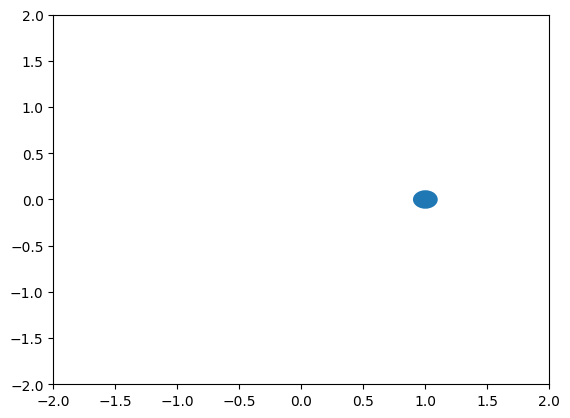

In [22]:
import diplotocus as dpl
import numpy as np

tl = dpl.Timeline(xlim=(-2,2),ylim=(-2,2))

#s1 = dpl.scatter(1,0)
s1 = dpl.Circle(xy=(1,0),radius=.1)
s1.rotate(start_angle=0,end_angle=360,duration=60,center=(0,0))

#s2 = dpl.scatter(1,0.5)
s2 = dpl.text(1,0.5,"test",va="middle")
s2.rotate(start_angle=0,end_angle=-360,duration=60)
s2.rotate(start_angle=0,end_angle=360,duration=60,center=(0,0.5))

tl.animate((s1,s2))
tl.save_video('../../_static/examples/solar_system.mp4')

In [17]:
import diplotocus as dpl
import numpy as np

tl = dpl.Timeline(xlim=(-40,40),ylim=(-40,40),figsize=(5,5),noaxis=True,fig_color='k',bbox_inches='tight')

sun = dpl.Circle(xy=(0,0),radius=2,fc='yellow')
sun.plot(60)

planet_infos = [
    {'name':'Mercury','d':0.320,'r':0.2440,'col':'#bfbdbc'},
    {'name':'Venus'  ,'d':0.720,'r':0.6052,'col':'#d4b496'},
    {'name':'Earth'  ,'d':1.000,'r':0.6371,'col':'#6a87a5'},
    {'name':'Mars'   ,'d':1.400,'r':0.3390,'col':'#e38266'},
    {'name':'Jupiter','d':5.260,'r':6.9911,'col':'#bdb19e'},
    {'name':'Saturn' ,'d':9.480,'r':5.8232,'col':'#d4b880'},
    {'name':'Uranus' ,'d':19.47,'r':2.5362,'col':'#9dbabd'},
    {'name':'Neptune','d':29.88,'r':2.4622,'col':'#809dbc'},
]
planets = []
trails = []
names = []
for planet_info in planet_infos:
    d = planet_info['d']
    r = planet_info['r']
    c = planet_info['col']
    n = planet_info['name']
    r = np.sqrt(r)
    omega = d**(-3/2)*180*100

    planet = dpl.Circle(xy=(d,0),radius=r,fc=c,zorder=2)
    trail = dpl.Arc(width=2*d,height=2*d,xy=(0,0),theta1=-30,theta2=0,lw=3,ec=c,zorder=1)
    name = dpl.text(x=d,y=0.5,string=n,fc='w',lw=0,fontsize=15)

    planet.rotate(start_angle=0,end_angle=omega,center=(0,0),duration=120)
    trail.rotate(start_angle=0,end_angle=omega,center=(0,0),duration=120)
    name.rotate(start_angle=0,end_angle=-omega,duration=120)
    name.rotate(start_angle=0,end_angle=omega,center=(0,0.5),duration=120)
    
    planets.append(planet)
    trails.append(trail)
    names.append(name)

a1 = dpl.axis_track(planets[5],duration=120)
a2 = dpl.axis_zoom(zoom=2,duration=120)

t = dpl.text(0,0,"Time : {_dpl_frame/120:.2f} Gyr",eval=True,fc='w',lw=0,fontsize=25)
t.plot(120)

tl.animate((sun,*planets,*trails,*names,a1,a2,t))

a2 = dpl.axis_zoom(zoom=0.5,duration=120)
t.plot(120)
tl.animate((a2,t))

tl.save_video('../../_static/examples/solar_system.mp4')

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

Saved video ../../_static/examples/solar_system.mp4

In [13]:
from IPython.display import HTML, display
display(HTML("""
    <video width="640" height="460" autoplay loop muted playsinline>
    <source src="../../_static/examples/fit.mp4?randId={}" type="video/mp4">
    </video>
"""))